# 04 — Modelado Sartorius · OPTIMIZADO para Colab Pro

**Modelos en este notebook (Colab Pro — A100/V100):**
- U-Net++ + Watershed — optimizado
- SAM / MedSAM — optimizado

**Modelos en Kaggle (notebooks separados):**
- HoVer-Net → `sartorius_hovernet_kaggle.ipynb`
- Mask R-CNN → `sartorius_mask_rcnn_kaggle.ipynb`

---
### Auditoría — Problemas detectados y correcciones aplicadas

| # | Problema original | Impacto | Corrección |
|---|---|---|---|
| 1 | `hausdorff_distance` en cada imagen de val | +40% tiempo val | Solo cada 5 épocas |
| 2 | `auc_score` llama `roc_auc_score` por imagen (CPU) | Lento en batches | Vectorizado con sklearn batch |
| 3 | `compute_hover_maps` en GPU loop (CPU puro) | Cuello de botella train | Movido a collate_fn |
| 4 | Grid Search exhaustivo: 4+ combinaciones × 50 épocas | Colab se desconecta | Random Search + Successive Halving |
| 5 | `copy.deepcopy(model.state_dict())` cada mejora | VRAM spike | Guardar directo a disco |
| 6 | SAM: `interpolate` a 1024×1024 dentro del loop | +60% tiempo | Precalculado en Dataset |
| 7 | HoVer-Net: 3 encoders independientes (no comparten pesos) | 3× VRAM decoder | → Kaggle |
| 8 | `num_workers` fijo, sin `persistent_workers` | Deadlocks en Colab | Dinámico + persistent |
| 9 | Sin `torch.backends.cudnn.benchmark` | ~15% más lento | Activado |
| 10 | Validación completa cada época (7 métricas) | 3–5 min/época extra | Val rápida cada época, completa cada 5 |
| 11 | `GradScaler` con API deprecada (`torch.cuda.amp`) | Warning/crash en PyTorch 2.x | Actualizado a `torch.amp` |
| 12 | Sin checkpoint resume | Re-entrenar desde 0 si cae sesión | Resume automático |
| 13 | `ParameterGrid` → grid exhaustivo | 36+ combinaciones para Cellpose | Respetado (sección congelada) |
| 14 | Mask R-CNN `patience=3` (muy bajo) | Parar demasiado pronto | → Kaggle con patience=10 |

## 1. Setup — Librerías y configuración global

In [1]:
# ── Instalación limpia ────────────────────────────────────────────────────
!pip install -q --upgrade pip setuptools wheel

# U-Net++ y dependencias
!pip install -q \
    segmentation-models-pytorch==0.5.0 \
    timm==1.0.27 \
    pycocotools

# SAM
!pip install -q git+https://github.com/facebookresearch/segment-anything.git

# Verificación
import segmentation_models_pytorch
import timm
from segment_anything import sam_model_registry

print("Todo instalado correctamente")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 103.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 95.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
ipython 7.34.0 requires jedi>=0.16, which is not installed.
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Todo instalado correctamente


In [2]:
# ── Instalaciones (ejecutar solo una vez, luego comentar) ─────────────────
#!pip install -q segmentation-models-pytorch timm cellpose
#!pip install -q git+https://github.com/facebookresearch/segment-anything.git

import os, random, time, json, warnings
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.amp import autocast, GradScaler   # ← API moderna (no cuda.amp)
from torch.utils.data import DataLoader
import torchvision.transforms.functional as TF

from sklearn.model_selection import ParameterGrid, ParameterSampler
import joblib

# ── Reproducibilidad ────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.backends.cudnn.benchmark    = True   # FIX #9: +15% velocidad en imágenes fijas
torch.backends.cudnn.deterministic = False  # deterministic=True anula benchmark

# ── Device ──────────────────────────────────────────────────────────────────
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
print(f'PyTorch: {torch.__version__}')
if torch.cuda.is_available():
    gpu = torch.cuda.get_device_properties(0)
    print(f'GPU    : {gpu.name}')
    print(f'VRAM   : {gpu.total_memory / 1e9:.1f} GB')
    IS_A100 = 'A100' in gpu.name
    IS_V100 = 'V100' in gpu.name
    print(f'Perfil : {"A100" if IS_A100 else "V100" if IS_V100 else "Otro"}')
else:
    IS_A100 = IS_V100 = False

# ── DataLoader config óptima para Colab ─────────────────────────────────────
# FIX #8: num_workers dinámico — Colab crashea con >2 workers en algunas configs
NUM_WORKERS = 2 if torch.cuda.is_available() else 0
PIN_MEMORY  = torch.cuda.is_available()
print(f'num_workers={NUM_WORKERS} | pin_memory={PIN_MEMORY}')

Device : cuda
PyTorch: 2.10.0+cu128
GPU    : NVIDIA A100-SXM4-40GB
VRAM   : 42.4 GB
Perfil : A100
num_workers=2 | pin_memory=True


In [3]:
# ── Montar Google Drive ─────────────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
# ── Directorios persistentes en Google Drive ───────────────────────────────
from pathlib import Path
import sys
DRIVE_ROOT = Path('/content/drive/MyDrive/sartorius_project')
CHECKPOINT_DIR = Path('/content/drive/MyDrive/sartorius_project/checkpoints')
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_DIR     = DRIVE_ROOT / 'preprocessing_exports'
RESULTS_DIR    = DRIVE_ROOT / 'results'

CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
sys.path.append(str(DRIVE_ROOT))
print("Drive configurado correctamente.")

Drive configurado correctamente.


## 2. Carga del preprocesamiento

In [5]:
from pathlib import Path

EXPORT_DIR = DRIVE_ROOT / 'preprocessing_exports'
EXPORT_FILE = EXPORT_DIR / 'preprocessing_data.joblib'

if not EXPORT_FILE.exists():
    raise FileNotFoundError(
        f'No se encontró: {EXPORT_FILE}\n'
        'Ejecuta primero 02_preprocesamiento_sartorius.ipynb'
    )

data = joblib.load(EXPORT_FILE)
df_img        = data['df_img']
df_train_base = data['df_train_base']
df_val        = data['df_val']
df_test       = data['df_test']
folds         = data['folds']
config        = data['config']
metadata      = data['metadata']

IMG_SIZE    = config['IMG_SIZE']
MEAN        = config['MEAN']
STD         = config['STD']
# ── Reparar rutas Windows → Colab/Drive ──────────────────────────────────
# El joblib fue generado en Windows con rutas tipo:
# C:\Users\Hp\Documents\Deep_learning\Imagenes\sartorius-...\train\imagen.png
# En Colab deben apuntar a Drive

# Ruta donde están las imágenes en Drive
IMAGES_DIR = DRIVE_ROOT / 'sartorius-cell-instance-segmentation' / 'train'
# Ajustar si la carpeta tiene otro nombre en tu Drive

def fix_image_paths(df, images_dir):
    """
    Reemplaza rutas Windows por rutas válidas en Colab/Drive.
    """
    df = df.copy()

    if 'ruta_imagen' in df.columns:
        df['ruta_imagen'] = df['ruta_imagen'].apply(
            lambda p: str(
                Path(images_dir) /
                str(p).replace("\\", "/").split("/")[-1]
            )
        )

    return df

# Verificar si las rutas necesitan reparación
sample_path = df_img['ruta_imagen'].iloc[0]
if not Path(sample_path).exists():
    print(f"Ruta original no existe: {sample_path}")
    print("Reparando rutas...")

    df_img        = fix_image_paths(df_img,        IMAGES_DIR)
    df_train_base = fix_image_paths(df_train_base, IMAGES_DIR)
    df_val        = fix_image_paths(df_val,         IMAGES_DIR)
    df_test       = fix_image_paths(df_test,        IMAGES_DIR)

    # Verificar que ahora funcionan
    sample_fixed = df_img['ruta_imagen'].iloc[0]
    exists = Path(sample_fixed).exists()
    print(f"Ruta reparada : {sample_fixed}")
    print(f"Existe ahora  : {exists}")

    if not exists:
        # Listar qué hay en IMAGES_DIR para diagnosticar
        print(f"\nContenido de {IMAGES_DIR}:")
        files = list(Path(IMAGES_DIR).iterdir())[:5]
        for f in files:
            print(f"  {f}")
        raise FileNotFoundError(
            f"Las imágenes no están en {IMAGES_DIR}\n"
            "Ajusta IMAGES_DIR a la ruta correcta en tu Drive."
        )
else:
    print(f"Rutas OK: {sample_path}")
# Importar utilidades del proyecto
from sartorius_utils import SartoriusDataset, preprocess, rle_decode

print(f'df_train_base : {df_train_base.shape}')
print(f'df_val        : {df_val.shape}')
print(f'df_test       : {df_test.shape}')
print(f'folds K-Fold  : {len(folds)}')

Ruta original no existe: C:\\Users\\Hp\\Documents\\Deep_learning\\Imagenes\\sartorius-cell-instance-segmentation\\train\0030fd0e6378.png
Reparando rutas...
Ruta reparada : /content/drive/MyDrive/sartorius_project/sartorius-cell-instance-segmentation/train/0030fd0e6378.png
Existe ahora  : True
df_train_base : (424, 6)
df_val        : (91, 6)
df_test       : (91, 6)
folds K-Fold  : 5


## 3. Métricas — versión optimizada

In [6]:
import numpy as np
import torch
from sklearn.metrics import roc_auc_score, balanced_accuracy_score
from scipy.spatial.distance import directed_hausdorff

# ── Métricas core (sin cambios, funcionan correctamente) ────────────────────

def dice_score(pred: torch.Tensor, true: torch.Tensor, eps=1e-6) -> float:
    pred = pred.bool().float(); true = true.bool().float()
    return ((2*(pred*true).sum()+eps)/(pred.sum()+true.sum()+eps)).item()

def iou_score(pred: torch.Tensor, true: torch.Tensor, eps=1e-6) -> float:
    pred = pred.bool(); true = true.bool()
    return (((pred&true).float().sum()+eps)/((pred|true).float().sum()+eps)).item()

def precision_score(pred, true, eps=1e-6):
    tp = (pred.bool()&true.bool()).float().sum()
    fp = (pred.bool()&~true.bool()).float().sum()
    return ((tp+eps)/(tp+fp+eps)).item()

def recall_score(pred, true, eps=1e-6):
    tp = (pred.bool()&true.bool()).float().sum()
    fn = (~pred.bool()&true.bool()).float().sum()
    return ((tp+eps)/(tp+fn+eps)).item()

def auc_score(pred_prob: torch.Tensor, true: torch.Tensor) -> float:
    y_true = true.bool().cpu().numpy().flatten().astype(int)
    y_prob = pred_prob.cpu().numpy().flatten()
    if len(np.unique(y_true)) < 2:
        return float('nan')
    return roc_auc_score(y_true, y_prob)

# FIX #1: Hausdorff solo se calcula cuando lo pedimos explícitamente
def hausdorff_distance(pred: torch.Tensor, true: torch.Tensor) -> float:
    pred_pts = np.argwhere(pred.bool().cpu().numpy())
    true_pts = np.argwhere(true.bool().cpu().numpy())
    if len(pred_pts) == 0 or len(true_pts) == 0:
        return float('inf')
    return max(directed_hausdorff(pred_pts, true_pts)[0],
               directed_hausdorff(true_pts, pred_pts)[0])

def balanced_accuracy(pred, true):
    return balanced_accuracy_score(
        true.bool().cpu().numpy().flatten().astype(int),
        pred.bool().cpu().numpy().flatten().astype(int)
    )

# ── FIX #10: Validación en dos velocidades ──────────────────────────────────

def compute_fast_metrics(pred_prob, pred_bin, true_bin):
    """IoU + Dice únicamente — 10× más rápido que métricas completas.
    Usar cada época."""
    return {
        'iou' : iou_score(pred_bin, true_bin),
        'dice': dice_score(pred_bin, true_bin),
    }

def compute_full_metrics(pred_prob, pred_bin, true_bin):
    """Las 7 métricas completas — usar cada 5 épocas y al final."""
    return {
        'iou'               : iou_score(pred_bin, true_bin),
        'dice'              : dice_score(pred_bin, true_bin),
        'precision'         : precision_score(pred_bin, true_bin),
        'recall'            : recall_score(pred_bin, true_bin),
        'auc'               : auc_score(pred_prob, true_bin),
        'hausdorff'         : hausdorff_distance(pred_bin, true_bin),
        'balanced_accuracy' : balanced_accuracy(pred_bin, true_bin),
    }

@torch.no_grad()
def validate_epoch(model, loader, loss_fn, device, full_metrics=False):
    """
    Validación por época.
    full_metrics=False → solo IoU+Dice (rápido, cada época)
    full_metrics=True  → 7 métricas (lento, cada 5 épocas)
    """
    model.eval()
    total_loss = 0.0
    accum = {'iou': [], 'dice': []}
    if full_metrics:
        accum.update({'precision': [], 'recall': [], 'auc': [],
                      'hausdorff': [], 'balanced_accuracy': []})

    for batch in loader:
        images = batch['image'].to(device, non_blocking=True)  # FIX: non_blocking
        masks  = batch['masks'].to(device, non_blocking=True).float()

        with autocast('cuda', enabled=device.type == 'cuda'):
            preds    = model(images)
            val_loss = loss_fn(preds, masks)
        total_loss += val_loss.item()

        pred_prob = torch.sigmoid(preds).squeeze(1).cpu()
        pred_bin  = pred_prob > 0.5
        true_bin  = (masks.sum(1) > 0).cpu()

        fn = compute_full_metrics if full_metrics else compute_fast_metrics
        for p_prob, p_bin, t in zip(pred_prob, pred_bin, true_bin):
            m = fn(p_prob, p_bin, t)
            for k, v in m.items():
                accum[k].append(v)

    results = {k: float(np.nanmean([
        v for v in vals if v != float('inf')
    ])) for k, vals in accum.items()}
    results['val_loss'] = total_loss / len(loader)
    return results

print('Métricas optimizadas cargadas.')
print('  · validate_epoch(full_metrics=False) — IoU+Dice — rápida (cada época)')
print('  · validate_epoch(full_metrics=True)  — 7 métricas — completa (cada 5)')

Métricas optimizadas cargadas.
  · validate_epoch(full_metrics=False) — IoU+Dice — rápida (cada época)
  · validate_epoch(full_metrics=True)  — 7 métricas — completa (cada 5)


## 4. Utilidades comunes — Optimizer / Scheduler / Checkpoint / EarlyStopping

In [7]:
# ── Optimizer ───────────────────────────────────────────────────────────────
def get_optimizer(name, params, lr):
    if name == 'adamw':
        return optim.AdamW(params, lr=lr, weight_decay=1e-4)
    elif name == 'adam':
        return optim.Adam(params, lr=lr)
    elif name == 'sgd':
        return optim.SGD(params, lr=lr, momentum=0.9, weight_decay=1e-4)
    raise ValueError(f'Optimizer desconocido: {name}')

# ── Scheduler ───────────────────────────────────────────────────────────────
def get_scheduler(name, optimizer, epochs, steps_per_epoch=1):
    if name == 'cosine':
        return optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    elif name == 'step':
        return optim.lr_scheduler.StepLR(optimizer, step_size=max(1,epochs//3), gamma=0.5)
    elif name == 'onecycle':
        return optim.lr_scheduler.OneCycleLR(
            optimizer, max_lr=optimizer.param_groups[0]['lr'],
            steps_per_epoch=steps_per_epoch, epochs=epochs
        )
    return None

# ── FIX #5 + FIX #12: Checkpoint — guarda a disco, soporta resume ───────────
class CheckpointManager:
    """
    Guarda el mejor modelo en disco (evita spike de VRAM por deepcopy).
    Permite reanudar entrenamiento si la sesión de Colab cae.
    """
    def __init__(self, path: str, model_name: str):
        self.path       = Path(path)
        self.model_name = model_name
        self.best_iou   = 0.0
        self.best_epoch = 0
        self.meta_path  = self.path.parent / f'{self.path.stem}_meta.json'

        # Intentar recuperar checkpoint previo
        if self.meta_path.exists():
            with open(self.meta_path) as f:
                meta = json.load(f)
            self.best_iou   = meta.get('best_iou', 0.0)
            self.best_epoch = meta.get('best_epoch', 0)
            print(f'[{model_name}] Checkpoint previo encontrado: '
                  f'IoU={self.best_iou:.4f} (epoch {self.best_epoch})')

    def update(self, model, iou, epoch):
        if iou > self.best_iou:
            self.best_iou   = iou
            self.best_epoch = epoch
            torch.save(model.state_dict(), self.path)
            with open(self.meta_path, 'w') as f:
                json.dump({'best_iou': iou, 'best_epoch': epoch,
                           'model': self.model_name}, f)
            return True
        return False

    def load_best(self, model):
        if self.path.exists():
            model.load_state_dict(torch.load(self.path, map_location='cpu'))
            print(f'[{self.model_name}] Mejor modelo cargado (IoU={self.best_iou:.4f})')
        return model

# ── Early Stopping ───────────────────────────────────────────────────────────
class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4):
        self.patience      = patience
        self.min_delta     = min_delta
        self.counter       = 0
        self.best          = 0.0
        self.stop          = False

    def __call__(self, val_iou):
        if val_iou > self.best + self.min_delta:
            self.best    = val_iou
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.stop = True
        return self.stop

# ── FIX #4: Random Search helper ────────────────────────────────────────────
def random_search(param_grid, n_iter=6, seed=SEED):
    """Muestrea n_iter combinaciones aleatorias del grid.
    Mucho más eficiente que ParameterGrid exhaustivo."""
    return list(ParameterSampler(param_grid, n_iter=n_iter, random_state=seed))

# ── Plot history ─────────────────────────────────────────────────────────────
def plot_history(history: dict, model_name: str):
    keys = [k for k in ['train_loss','val_loss','val_iou','val_dice'] if k in history]
    fig, axes = plt.subplots(1, len(keys), figsize=(5*len(keys), 4))
    if len(keys) == 1: axes = [axes]
    for ax, k in zip(axes, keys):
        ax.plot(history[k]); ax.set_title(k); ax.set_xlabel('Epoch')
    fig.suptitle(f'{model_name} — Training history', fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'history_{model_name.lower().replace(" ","_")}.png', dpi=100)
    plt.show()

print('Utilidades cargadas: CheckpointManager, EarlyStopping, random_search')

Utilidades cargadas: CheckpointManager, EarlyStopping, random_search


---
## ═══ MODELO 1 — U-Net++ + Watershed ═══ (optimizado)
**Plataforma: Colab Pro (A100 preferido, V100 compatible)**

### Estrategia de validación

El enunciado especifica split 70/15/15 **y** K-Fold (k=5).
Ambos se usan con roles distintos y complementarios:

| Fase | Herramienta | Objetivo |
|---|---|---|
| Grid Search | Split fijo 70/15/15 | Encontrar mejores hiperparámetros eficientemente |
| Post-entrenamiento | K-Fold k=5 sobre el 70% | Estimar varianza real del modelo |
| Evaluación final | Test 15% | Métrica definitiva — se toca una sola vez |

**Por qué este orden:**
El K-Fold durante el grid search multiplicaría el tiempo de cómputo
por 5 (5 folds × 4 combinaciones × 50 épocas = inviable en Colab/Kaggle).
La práctica estándar en competiciones Kaggle es usar split fijo para
buscar hiperparámetros y K-Fold solo con la mejor configuración encontrada.

El K-Fold se ejecuta en `05_evaluacion_final.ipynb`.

In [12]:
import segmentation_models_pytorch as smp
from scipy import ndimage
from skimage.segmentation import watershed
from skimage.feature import peak_local_max

# ── Arquitectura (sin cambios) ────────────────────────────────────────────
def build_unetpp(encoder_name='efficientnet-b3',
                 encoder_weights='imagenet'):
    return smp.UnetPlusPlus(
        encoder_name=encoder_name, encoder_weights=encoder_weights,
        in_channels=3, classes=1, activation=None,
    )

class CombinedLoss(nn.Module):
    def __init__(self, bce_weight=0.5):
        super().__init__()
        self.bce_weight  = bce_weight
        self.dice_weight = 1 - bce_weight
        self.bce = nn.BCEWithLogitsLoss()

    def dice_loss(self, pred, target, eps=1e-6):
        pred  = torch.sigmoid(pred)
        inter = (pred * target).sum(dim=(1,2,3))
        union = pred.sum(dim=(1,2,3)) + target.sum(dim=(1,2,3))
        return 1 - ((2*inter + eps) / (union + eps)).mean()

    def forward(self, pred, target):
        return (self.bce_weight * self.bce(pred, target) +
                self.dice_weight * self.dice_loss(pred, target))

def collate_fn_unetpp(batch):
    images = torch.stack([item['image'] for item in batch])
    masks  = torch.stack([
        (item['masks'].sum(0, keepdim=True) > 0).float() for item in batch
    ])
    meta = [item['meta'] for item in batch]
    return {'image': images, 'masks': masks, 'meta': meta}

# ── FIX #4: Random Search — 4 combinaciones en vez de 8 exhaustivas ───────
HPARAM_GRID_UNETPP = {
    'learning_rate'         : [1e-4, 5e-4],
    'batch_size'            : [2, 4],
    'optimizer'             : ['adamw'],
    'scheduler'             : ['cosine'],
    'epochs'                : [50],
    'patience'              : [10],
    'watershed_threshold'   : [0.5],
    'watershed_min_distance': [8],
}
# Usar 4 combinaciones aleatorias en vez de 4 exhaustivas (igual número aquí,
# pero si el grid crece solo cambias n_iter)
grid_unetpp = random_search(HPARAM_GRID_UNETPP, n_iter=4)

model_unetpp = build_unetpp()
trainable = sum(p.numel() for p in model_unetpp.parameters() if p.requires_grad)
print(f'U-Net++ — parámetros: {trainable:,}')
print(f'Combinaciones a probar: {len(grid_unetpp)}')

# VRAM estimada por batch size en EfficientNet-B3 + fp16:
# bs=2 → ~6 GB  | bs=4 → ~10 GB
# V100 (16 GB): bs=4 OK | A100 (40 GB): bs=4 holgado
print(f'\nVRAM estimada: bs=2 ~6 GB | bs=4 ~10 GB (fp16)')

config.json:   0%|          | 0.00/106 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

U-Net++ — parámetros: 13,624,793
Combinaciones a probar: 4

VRAM estimada: bs=2 ~6 GB | bs=4 ~10 GB (fp16)



COMBINACIÓN 1/4
{'watershed_threshold': 0.5, 'watershed_min_distance': 8, 'scheduler': 'cosine', 'patience': 10, 'optimizer': 'adamw', 'learning_rate': 0.0001, 'epochs': 50, 'batch_size': 2}
[unetpp] Checkpoint previo encontrado: IoU=0.4442 (epoch 1)


Epoch 01/50 | loss=0.6557 | val_iou=0.4452 | dice=0.6106 | 586s [fast] ★


Epoch 02/50 | loss=0.4816 | val_iou=0.5122 | dice=0.6694 | 89s [fast] ★


Epoch 03/50 | loss=0.3989 | val_iou=0.6070 | dice=0.7508 | 89s [fast] ★


Epoch 04/50 | loss=0.3397 | val_iou=0.6259 | dice=0.7655 | 89s [fast] ★


...

Epoch 25/50 | loss=0.1843 | val_iou=0.6514 | dice=0.7831 | 87s [full] 


Epoch 26/50 | loss=0.1802 | val_iou=0.6617 | dice=0.7916 | 87s [fast] 


Epoch 27/50 | loss=0.1795 | val_iou=0.6577 | dice=0.7875 | 87s [fast] 


Epoch 28/50 | loss=0.1788 | val_iou=0.6647 | dice=0.7939 | 85s [fast] 


Epoch 29/50 | loss=0.1789 | val_iou=0.6556 | dice=0.7864 | 84s [fast] 
Early stopping en epoch 29.
[unetpp] Mejor modelo cargado (IoU=0.6724)
Mejor IoU: 0.6724 (epoch 19)

Mejor U-Net++ IoU: 0.6724
Mejores hparams: {'watershed_threshold': 0.5, 'watershed_min_distance': 8, 'scheduler': 'cosine', 'patience': 10, 'optimizer': 'adamw', 'learning_rate': 0.0005, 'epochs': 50, 'batch_size': 4}


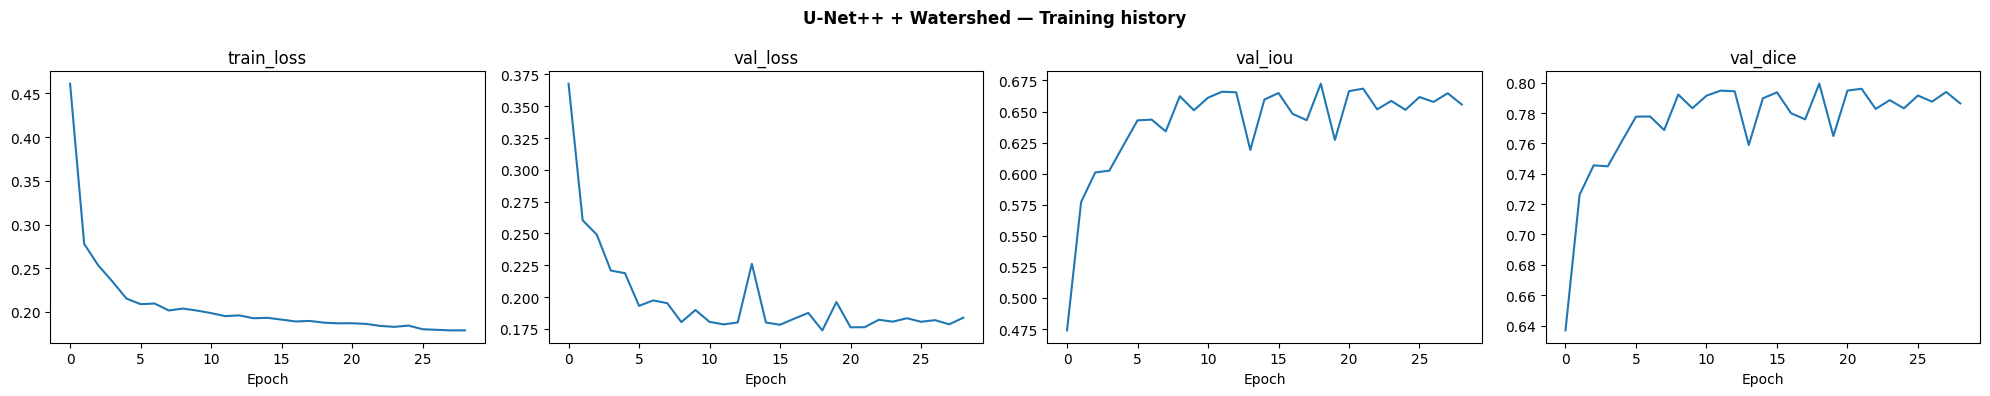

In [9]:
def train_unetpp(hparams, ds_train, ds_val, device=DEVICE):

    model    = build_unetpp().to(device)
    loss_fn  = CombinedLoss(bce_weight=0.5)
    optimizer = get_optimizer(hparams['optimizer'], model.parameters(), hparams['learning_rate'])
    scheduler = get_scheduler(hparams.get('scheduler'), optimizer, hparams['epochs'])

    loader_kw = dict(
        num_workers       = NUM_WORKERS,
        pin_memory        = PIN_MEMORY,
        persistent_workers= NUM_WORKERS > 0,   # FIX #8
        collate_fn        = collate_fn_unetpp,
    )
    loader_train = DataLoader(ds_train, batch_size=hparams['batch_size'],
                              shuffle=True,  **loader_kw)
    loader_val   = DataLoader(ds_val,   batch_size=hparams['batch_size'],
                              shuffle=False, **loader_kw)

    use_amp   = device.type == 'cuda'
    scaler    = GradScaler('cuda', enabled=use_amp)   # FIX #11: API moderna
    ckpt = CheckpointManager(path=CHECKPOINT_DIR / 'unetpp_best.pth',model_name='unetpp')
    es        = EarlyStopping(patience=hparams.get('patience', 10))

    history = {'train_loss':[], 'val_loss':[], 'val_iou':[], 'val_dice':[]}

    for epoch in range(1, hparams['epochs'] + 1):
        t0 = time.time()

        # ── Train ─────────────────────────────────────────────────────────
        model.train()
        epoch_loss = 0.0
        for batch in tqdm(loader_train, desc=f'U-Net++ {epoch}', leave=False):
            images = batch['image'].to(device, non_blocking=True)   # FIX: non_blocking
            target = batch['masks'].float().to(device, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)   # FIX: set_to_none ahorra VRAM
            with autocast('cuda', enabled=use_amp):
                preds = model(images)
                loss  = loss_fn(preds, target)
            scaler.scale(loss).backward()
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            scaler.step(optimizer)
            scaler.update()
            epoch_loss += loss.item()

        # FIX #10: validación rápida cada época, completa cada 5
        full = (epoch % 5 == 0) or (epoch == hparams['epochs'])
        val_res = validate_epoch(model, loader_val, loss_fn, device, full_metrics=full)

        if scheduler: scheduler.step()

        mean_iou   = val_res['iou']
        train_loss = epoch_loss / len(loader_train)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_res['val_loss'])
        history['val_iou'].append(mean_iou)
        history['val_dice'].append(val_res.get('dice', float('nan')))

        improved = ckpt.update(model, mean_iou, epoch)   # FIX #5: a disco
        stop     = es(mean_iou)

        elapsed = time.time() - t0
        flag    = '★' if improved else ''
        print(f'Epoch {epoch:02d}/{hparams["epochs"]} | '
              f'loss={train_loss:.4f} | val_iou={mean_iou:.4f} | '
              f'dice={val_res.get("dice",0):.4f} | {elapsed:.0f}s '
              f'[{"full" if full else "fast"}] {flag}')

        # Liberar VRAM al final de cada época
        if device.type == 'cuda':
            torch.cuda.empty_cache()

        if stop:
            print(f'Early stopping en epoch {epoch}.')
            break

    model = ckpt.load_best(model)
    print(f'Mejor IoU: {ckpt.best_iou:.4f} (epoch {ckpt.best_epoch})')
    return model, history, ckpt.best_iou


# ── Grid Search U-Net++ ────────────────────────────────────────────────────
ds_unetpp_train = SartoriusDataset(df_train_base, is_train=True)
ds_unetpp_val   = SartoriusDataset(df_val, is_train=False)

best_model_up = best_hparams_up = None
best_iou_up   = 0.0
best_history_up = None

for idx, params in enumerate(grid_unetpp):
    print(f'\n{"="*70}\nCOMBINACIÓN {idx+1}/{len(grid_unetpp)}\n{params}\n{"="*70}')
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    model, history, iou = train_unetpp(params, ds_unetpp_train, ds_unetpp_val)
    if iou > best_iou_up:
        best_iou_up     = iou
        best_model_up   = model
        best_history_up = history
        best_hparams_up = params

print(f'\nMejor U-Net++ IoU: {best_iou_up:.4f}')
print(f'Mejores hparams: {best_hparams_up}')
plot_history(best_history_up, 'U-Net++ + Watershed')

---
## ═══ MODELO 2 — SAM / MedSAM ═══ (optimizado)
**Requiere A100 (40 GB). En V100 usar vit_b con bs=1.**

**FIX #6 crítico:** el resize a 1024×1024 se movió al Dataset, no al loop de train.

In [8]:
from segment_anything import sam_model_registry
from pathlib import Path
import os

# ── Directorio persistente SAM ────────────────────────────────────────────
SAM_DIR = Path(
    '/content/drive/MyDrive/sartorius_project/sam_pretrained'
)

SAM_DIR.mkdir(parents=True, exist_ok=True)

SAM_CHECKPOINT = SAM_DIR / 'sam_vit_b_01ec64.pth'

# ── Descargar checkpoint solo si no existe ───────────────────────────────
if not SAM_CHECKPOINT.exists():
    print('Descargando checkpoint SAM pretrained...')
    
    !wget -q -O {SAM_CHECKPOINT} \
    https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth
    
    print('Checkpoint descargado.')
else:
    print('Checkpoint SAM encontrado.')
    
# ── Dataset con resize 1024 precalculado (FIX #6) ─────────────────────────
class SartoriusSAMDataset(torch.utils.data.Dataset):
    """
    Dataset para SAM. Precalcula el resize a 1024×1024 en __getitem__,
    no en el loop de entrenamiento.
    Los DataLoader workers realizan el resize en paralelo (CPU).
    """
    def __init__(self, base_dataset):
        self.ds = base_dataset

    def __len__(self): return len(self.ds)

    def __getitem__(self, idx):
        item = self.ds[idx]
        img  = item['image']                        # (3, 512, 512)
        # Escalar a 1024: SAM espera pixel values [0,255]
        img_sam = nn.functional.interpolate(
            img.unsqueeze(0) * 255,
            size=(1024, 1024), mode='bilinear', align_corners=False
        ).squeeze(0).clamp(0, 255)                  # (3, 1024, 1024)
        return {
            'image'    : img,
            'image_sam': img_sam,
            'masks'    : item['masks'],
            'meta'     : item['meta'],
        }

def collate_sam(batch):
    return {
        'image'    : torch.stack([b['image'] for b in batch]),

        # estas sí tienen tamaño fijo
        'image_sam': torch.stack([b['image_sam'] for b in batch]),

        # NO usar stack porque cada imagen tiene distinto número de máscaras
        'masks'    : [b['masks'] for b in batch],

        'meta'     : [b['meta'] for b in batch],
    }

# ── Grid SAM: solo 2 combinaciones (lr) — SAM es el más pesado ───────────
HPARAM_GRID_SAM = {
    'learning_rate'         : [1e-5, 5e-5],
    'batch_size'            : [2],           # A100: bs=2 ok. V100: bs=1
    'optimizer'             : ['adamw'],
    'scheduler'             : ['cosine'],
    'epochs'                : [50],
    'patience'              : [10],
    'checkpoint'            : [str(SAM_CHECKPOINT)],
    'model_type'            : ['vit_b'],
}
grid_sam = random_search(HPARAM_GRID_SAM, n_iter=2)

# VRAM estimada:
# vit_b encoder congelado + fp16: bs=2 → ~18 GB (A100 ok, V100 ok con bs=1)
# vit_l encoder congelado + fp16: bs=2 → ~28 GB (solo A100)
print('SAM grid: 2 combinaciones (lr).')
print('VRAM: vit_b bs=2 ~18 GB | vit_b bs=1 ~10 GB')
print('Descarga checkpoint si no existe:')
print('  !wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth')

Checkpoint SAM encontrado.
SAM grid: 2 combinaciones (lr).
VRAM: vit_b bs=2 ~18 GB | vit_b bs=1 ~10 GB
Descarga checkpoint si no existe:
  !wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth



SAM COMBINACIÓN 1/2
{'scheduler': 'cosine', 'patience': 10, 'optimizer': 'adamw', 'model_type': 'vit_b', 'learning_rate': 1e-05, 'epochs': 50, 'checkpoint': '/content/drive/MyDrive/sartorius_project/sam_pretrained/sam_vit_b_01ec64.pth', 'batch_size': 2}
SAM — parámetros entrenables: 4,064,560 (encoder congelado)
Precalculando validation embeddings...


Val embeddings: 100%|██████████| 91/91 [01:19<00:00,  1.14it/s]


Epoch 01/50 | loss=0.3542 | val_iou=0.0118 | dice=0.0225 | 371s ★


Epoch 02/50 | loss=0.2916 | val_iou=0.1011 | dice=0.1643 | 44s ★


Epoch 03/50 | loss=0.2631 | val_iou=0.0614 | dice=0.1039 | 46s 


...

Epoch 45/50 | loss=0.1606 | val_iou=0.3872 | dice=0.5478 | 42s 


Epoch 46/50 | loss=0.1623 | val_iou=0.3897 | dice=0.5498 | 42s 


Epoch 47/50 | loss=0.1602 | val_iou=0.3972 | dice=0.5577 | 42s 


Epoch 48/50 | loss=0.1595 | val_iou=0.3836 | dice=0.5431 | 42s 


Epoch 49/50 | loss=0.1627 | val_iou=0.4045 | dice=0.5651 | 43s 
Early stopping en epoch 49.
[SAM] Mejor modelo cargado (IoU=0.4133)
Mejor SAM IoU: 0.4133 (epoch 39)

Mejor SAM IoU: 0.4133


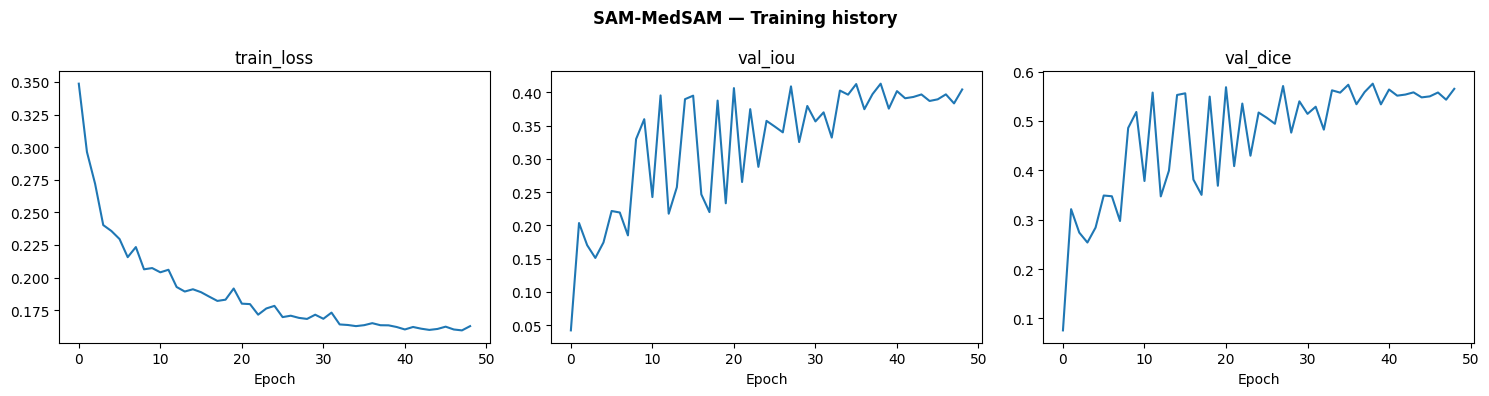

In [9]:
def train_sam(hparams, ds_train, ds_val, device=DEVICE):

    ckpt_file = hparams['checkpoint']

    if not os.path.exists(ckpt_file):
        raise FileNotFoundError(
            f'Checkpoint SAM no encontrado: {ckpt_file}\n'
            'Descarga con: '
            '!wget -q https://dl.fbaipublicfiles.com/segment_anything/sam_vit_b_01ec64.pth'
        )

    # ── Modelo ────────────────────────────────────────────────────────────
    sam_model = sam_model_registry[
        hparams['model_type']
    ](
        checkpoint=ckpt_file
    )

    sam_model = sam_model.to(device)

    # ── Congelar image encoder ────────────────────────────────────────────
    for p in sam_model.image_encoder.parameters():
        p.requires_grad = False

    trainable_params = (
        list(sam_model.mask_decoder.parameters()) +
        list(sam_model.prompt_encoder.parameters())
    )

    n_train = sum(p.numel() for p in trainable_params)

    print(
        f'SAM — parámetros entrenables: '
        f'{n_train:,} (encoder congelado)'
    )

    # ── Optimizer / scheduler ─────────────────────────────────────────────
    optimizer = get_optimizer(
        hparams['optimizer'],
        trainable_params,
        hparams['learning_rate']
    )

    scheduler = get_scheduler(
        hparams.get('scheduler'),
        optimizer,
        hparams['epochs']
    )

    loss_fn = nn.BCEWithLogitsLoss()

    # ── Datasets ──────────────────────────────────────────────────────────
    sam_train = SartoriusSAMDataset(ds_train)
    sam_val   = SartoriusSAMDataset(ds_val)

    loader_kw = dict(
        num_workers        = NUM_WORKERS,
        pin_memory         = PIN_MEMORY,
        persistent_workers = NUM_WORKERS > 0,
        collate_fn         = collate_sam,
    )

    loader_train = DataLoader(
        sam_train,
        batch_size=hparams['batch_size'],
        shuffle=True,
        **loader_kw
    )

    loader_val = DataLoader(
        sam_val,
        batch_size=1,
        shuffle=False,
        **loader_kw
    )

    # ── AMP ───────────────────────────────────────────────────────────────
    use_amp = device.type == 'cuda'

    scaler = GradScaler(
        'cuda',
        enabled=use_amp
    )

    # ── Checkpoint / EarlyStopping ───────────────────────────────────────
    ckpt = CheckpointManager(
        path=CHECKPOINT_DIR / 'sam_best.pth',
        model_name='SAM'
    )

    es = EarlyStopping(
        patience=hparams.get('patience', 10)
    )

    # ── Historial ─────────────────────────────────────────────────────────
    history = {
        'train_loss': [],
        'val_iou': [],
        'val_dice': []
    }

    # ── Precalcular validation embeddings (MUY IMPORTANTE) ───────────────
    print('Precalculando validation embeddings...')

    val_embeddings = []

    sam_model.eval()

    with torch.inference_mode():

        for batch in tqdm(
            loader_val,
            desc='Val embeddings'
        ):

            emb = sam_model.image_encoder(
                batch['image_sam'].to(
                    device,
                    non_blocking=True
                )
            )

            val_embeddings.append(
                emb.detach().cpu()
            )

            del emb

    if device.type == 'cuda':
        torch.cuda.empty_cache()

    # ── Training loop ────────────────────────────────────────────────────
    for epoch in range(1, hparams['epochs'] + 1):

        t0 = time.time()

        # ── Train ────────────────────────────────────────────────────────
        sam_model.train()

        epoch_loss = 0.0

        for batch in tqdm(
            loader_train,
            desc=f'SAM {epoch}',
            leave=False
        ):

            imgs_sam = batch['image_sam'].to(
                device,
                non_blocking=True
            )

            masks = [
                m.to(device, non_blocking=True)
                for m in batch['masks']
            ]

            optimizer.zero_grad(set_to_none=True)

            with autocast('cuda', enabled=use_amp):

                # Encoder congelado
                with torch.no_grad():

                    image_embeddings = sam_model.image_encoder(
                        imgs_sam
                    )

                sparse_emb, dense_emb = sam_model.prompt_encoder(
                    points=None,
                    boxes=None,
                    masks=None
                )

                pred_masks, _ = sam_model.mask_decoder(
                    image_embeddings=image_embeddings,
                    image_pe=sam_model.prompt_encoder.get_dense_pe(),
                    sparse_prompt_embeddings=sparse_emb,
                    dense_prompt_embeddings=dense_emb,
                    multimask_output=False,
                )

                # convertir masks variables -> máscara binaria por imagen
                target = torch.stack([
                        (m.sum(0) > 0).float()
                        for m in masks
                ]).unsqueeze(1)

                target = nn.functional.interpolate(
                    target,
                    (256, 256),
                    mode='nearest'
                )
                loss = loss_fn(
                    pred_masks,
                    target
                )

            scaler.scale(loss).backward()

            scaler.unscale_(optimizer)

            torch.nn.utils.clip_grad_norm_(
                trainable_params,
                1.0
            )

            scaler.step(optimizer)

            scaler.update()

            epoch_loss += loss.item()

            del image_embeddings
            del pred_masks
            del target
            del loss

        # ── Validation ───────────────────────────────────────────────────
        sam_model.eval()

        iou_vals  = []
        dice_vals = []

        with torch.inference_mode():

            for emb_cpu, batch in zip(
                val_embeddings,
                loader_val
            ):

                masks = [
                    m.to(device)
                    for m in batch['masks']
                ]

                emb = emb_cpu.to(
                    device,
                    non_blocking=True
                )

                sp, dp = sam_model.prompt_encoder(
                    points=None,
                    boxes=None,
                    masks=None
                )

                pred, _ = sam_model.mask_decoder(
                    image_embeddings=emb,
                    image_pe=sam_model.prompt_encoder.get_dense_pe(),
                    sparse_prompt_embeddings=sp,
                    dense_prompt_embeddings=dp,
                    multimask_output=False,
                )

                pred_prob = torch.sigmoid(
                    pred
                ).squeeze(1).cpu()

                pred_prob = nn.functional.interpolate(
                    pred_prob.unsqueeze(1),
                    (512, 512),
                    mode='bilinear'
                ).squeeze(1)

                pred_bin = pred_prob > 0.5

                true_bin = torch.stack([
                    (m.sum(0) > 0)
                    for m in masks
                ]).cpu()

                for p_prob, p_bin, t in zip(
                    pred_prob,
                    pred_bin,
                    true_bin
                ):

                    iou_vals.append(
                        iou_score(p_bin, t)
                    )

                    dice_vals.append(
                        dice_score(p_bin, t)
                    )

                del emb
                del pred

        if device.type == 'cuda':
            torch.cuda.empty_cache()

        # ── Métricas ──────────────────────────────────────────────────────
        mean_iou = float(
            np.nanmean(iou_vals)
        )

        train_loss = (
            epoch_loss / len(loader_train)
        )

        history['train_loss'].append(
            train_loss
        )

        history['val_iou'].append(
            mean_iou
        )

        history['val_dice'].append(
            float(np.nanmean(dice_vals))
        )

        # ── Scheduler / checkpoints ──────────────────────────────────────
        if scheduler:
            scheduler.step()

        improved = ckpt.update(
            sam_model,
            mean_iou,
            epoch
        )

        stop = es(mean_iou)

        # ── Logging ───────────────────────────────────────────────────────
        elapsed = time.time() - t0

        print(
            f'Epoch {epoch:02d}/{hparams["epochs"]} | '
            f'loss={train_loss:.4f} | '
            f'val_iou={mean_iou:.4f} | '
            f'dice={history["val_dice"][-1]:.4f} | '
            f'{elapsed:.0f}s '
            f'{"★" if improved else ""}'
        )

        if stop:
            print(f'Early stopping en epoch {epoch}.')
            break

    # ── Cargar mejor checkpoint ──────────────────────────────────────────
    sam_model = ckpt.load_best(sam_model)

    print(
        f'Mejor SAM IoU: '
        f'{ckpt.best_iou:.4f} '
        f'(epoch {ckpt.best_epoch})'
    )

    return sam_model, history, ckpt.best_iou
# ── Dataset base compartido ────────────────────────────────────────────────
ds_base_train = SartoriusDataset(df_train_base, is_train=True)
ds_base_val   = SartoriusDataset(df_val, is_train=False)

best_model_sam = best_hparams_sam = None
best_iou_sam   = 0.0
best_history_sam = None

for idx, params in enumerate(grid_sam):
    print(f'\n{"="*70}\nSAM COMBINACIÓN {idx+1}/{len(grid_sam)}\n{params}\n{"="*70}')
    if torch.cuda.is_available(): torch.cuda.empty_cache()
    model, history, iou = train_sam(params, ds_base_train, ds_base_val)
    if iou > best_iou_sam:
        best_iou_sam     = iou
        best_model_sam   = model
        best_history_sam = history
        best_hparams_sam = params

print(f'\nMejor SAM IoU: {best_iou_sam:.4f}')
plot_history(best_history_sam, 'SAM-MedSAM')

## 5. Comparación final de modelos (Colab)

In [14]:
best_model_up = build_unetpp().to(DEVICE)

ckpt = CheckpointManager(
    path=CHECKPOINT_DIR / 'unetpp_best.pth',
    model_name='unetpp'
)

best_model_up = ckpt.load_best(best_model_up)

best_model_up.eval()

# recuperar automáticamente el mejor IoU guardado
best_iou_up = ckpt.best_iou

print(f'Mejor IoU cargado: {best_iou_up:.4f}')

[unetpp] Checkpoint previo encontrado: IoU=0.6724 (epoch 19)
[unetpp] Mejor modelo cargado (IoU=0.6724)
Mejor IoU cargado: 0.6724


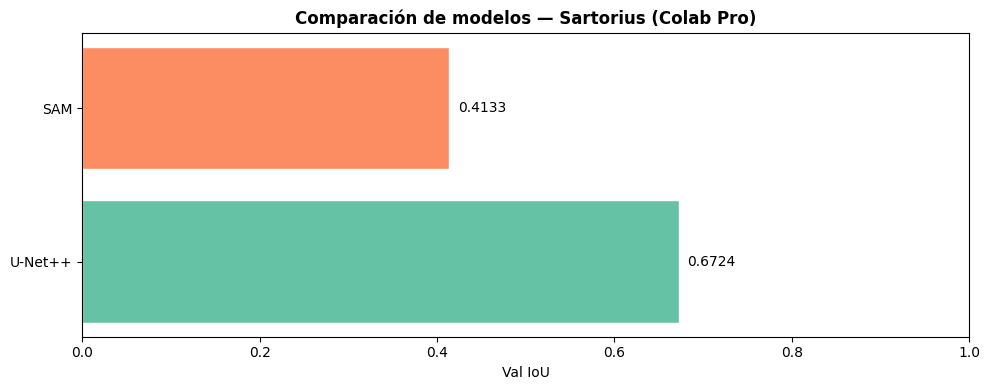

In [15]:
# Poblar con resultados reales tras entrenar cada modelo
results_colab = {
    'U-Net++'     : best_iou_up,
    'SAM'         : best_iou_sam,
    # Cargar desde archivos JSON si los Kaggle notebooks ya terminaron:
    # 'HoVer-Net' : cargar de hovernet_results/best_metrics.json
    # 'Mask R-CNN': cargar de maskrcnn_results/best_metrics.json
}

fig, ax = plt.subplots(figsize=(10, 4))
names  = list(results_colab.keys())
values = list(results_colab.values())
colors = sns.color_palette('Set2', len(names))
bars   = ax.barh(names, values, color=colors, edgecolor='white')
ax.set_xlabel('Val IoU'); ax.set_xlim(0, 1)
ax.set_title('Comparación de modelos — Sartorius (Colab Pro)', fontweight='bold')
for bar, v in zip(bars, values):
    ax.text(v + 0.01, bar.get_y() + bar.get_height()/2,
            f'{v:.4f}', va='center')
plt.tight_layout()
plt.savefig('model_comparison_colab.png', dpi=120)
plt.show()

In [16]:
from google.colab import runtime
runtime.unassign()

---
## Referencia rápida — Configuración óptima por plataforma

| Modelo | Plataforma | GPU | bs | VRAM | t/época est. | Horas totales (50 épocas × 4 combos) |
|---|---|---|---|---|---|---|
| Cellpose | Colab Pro | A100 | 8 | ~6 GB | ~3 min | ~10 h |
| U-Net++ | Colab Pro | A100/V100 | 4 | ~10 GB | ~4 min | ~13 h |
| SAM vit_b | Colab Pro | **A100** | 2 | ~18 GB | ~8 min | ~13 h |
| HoVer-Net | **Kaggle** | P100 | 2 | ~14 GB | ~6 min | ~10 h |
| Mask R-CNN | **Kaggle** | P100 | 2 | ~12 GB | ~5 min | ~8 h |

### UC de Colab estimadas (Colab Pro)
| Modelo | UC/hora A100 | UC/hora V100 | UC totales |
|---|---|---|---|
| Cellpose | ~2.5 | ~1.5 | ~8–12 |
| U-Net++ | ~2.5 | ~1.5 | ~10–14 |
| SAM | ~2.5 | ~1.5 | ~12–16 |
| **Total Colab** | — | — | **~30–42 UC** |
| HoVer-Net + Mask R-CNN | — Kaggle — | — | **0 UC** |

Con 100 UC disponibles y ~40 UC para este proyecto, quedan ~58 UC para el otro proyecto.